# Personal Information
Name: **Christos Georghiou**

StudentID: **16072766**

Email: [**christos.georghiou@student.uva.nl**](youremail@student.uva.nl)

Github: [Link](https://github.com/ChrisGeo729/msc-thesis-tiktok-multimodal-classification.git)

Submitted on: **23.03.2026**

# Data Context

This project uses two datasets: TKGO and YouTube-8M-Text. TKGO was accessed via Metabase in collaboration with AI Forensics and contains TikTok videos with associated transcripts and metadata, enabling multimodal analysis of short-form content. YouTube-8M-Text was obtained using publicly available code from the original YouTube-8M authors and extended to include textual features such as titles, descriptions, and tags. It provides a large-scale dataset for text-based video representation.

The two datasets allow comparison between short-form multimodal TikTok data and large-scale text-based YouTube data.

# Data Description

## Imports

In [6]:
import re
import json
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from langdetect import detect, LangDetectException


## 1. TikTok Global Observatory (TKGO)

### 1.1 Loading the Data

Two versions of the TKGO dataset are loaded:

- **`videos_unique.csv`** — the deduplicated dataset prior to caption enrichment (222,552 unique videos), used as a baseline reference to measure the impact of transcript collection.
- **`query_with_captions_filled.csv`** — the enriched dataset with additional transcripts collected via the pipeline described in section 1.4. This is the working dataset used throughout this analysis.

In addition to captions, thumbnail images have been collected separately for each video and will be transformed into visual feature vectors at a later stage of the thesis. Thumbnail availability is not analyzed here as the visual pipeline is handled independently.

In [7]:
df_tkgo = pd.read_csv("../data/TikTok/videos_unique.csv")
df = pd.read_csv("../data/TikTok/query_with_captions_filled.csv")

/var/folders/1n/p856mw397mv8kfjd3gjc5h7h0000gn/T/ipykernel_30582/1960570396.py:1: DtypeWarning: Columns (24,30,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tkgo = pd.read_csv("../data/TikTok/videos_unique.csv")
/var/folders/1n/p856mw397mv8kfjd3gjc5h7h0000gn/T/ipykernel_30582/1960570396.py:2: DtypeWarning: Columns (24,30,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/TikTok/query_with_captions_filled.csv")


In [8]:
print(df.shape)

(222552, 36)


In [9]:
print(df.columns)

Index(['Hash', 'Cls', 'AuthorFollowers', 'AuthorFollowing', 'AuthorId',
       'AuthorName', 'AuthorProfileLikes', 'AuthorVideoLikes', 'AuthorVideos',
       'Captions', 'Comments', 'CountryCode', 'CreateTime', 'Creation Date',
       'CurlId', 'CurlTime', 'Description', 'Duration', 'Labels', 'Likes',
       'Modified Date', 'MusicAuthor', 'MusicDuration', 'MusicId',
       'MusicOriginal', 'MusicTitle', 'Nickname', 'Order', 'Schema Version',
       'Shares', 'VideoId', 'Views', 'Caption Attempts', 'DiversificationId',
       'State Code', 'HtmlEvidence'],
      dtype='object')


In [10]:
print(df.dtypes)

Hash                   object
Cls                    object
AuthorFollowers       float64
AuthorFollowing       float64
AuthorId              float64
AuthorName             object
AuthorProfileLikes    float64
AuthorVideoLikes      float64
AuthorVideos          float64
Captions               object
Comments              float64
CountryCode            object
CreateTime             object
Creation Date          object
CurlId                 object
CurlTime               object
Description            object
Duration              float64
Labels                 object
Likes                 float64
Modified Date          object
MusicAuthor            object
MusicDuration         float64
MusicId               float64
MusicOriginal          object
MusicTitle             object
Nickname               object
Order                   int64
Schema Version          int64
Shares                float64
VideoId                object
Views                 float64
Caption Attempts        int64
Diversific

In [11]:
df.head()

,Hash,Cls,AuthorFollowers,AuthorFollowing,AuthorId,AuthorName,AuthorProfileLikes,AuthorVideoLikes,AuthorVideos,Captions,...,Nickname,Order,Schema Version,Shares,VideoId,Views,Caption Attempts,DiversificationId,State Code,HtmlEvidence
0,82ae050b4e33de5509dd78ecf328c474376cf87e,TKGlobalForYouVideo,149200.0,9560.0,6.812821e+18,alloshw1,9802.0,144400.0,41.0,NaN,...,دعم حسابات,0,1,1790.0,7205241760593841414,148500.0,1,NaN,NaN,NaN
1,9699d98cbe6f2eb9eae629f3a55f6e99105b098a,TKGlobalForYouVideo,847900.0,0.0,7.137576e+18,hungvinhchi4,0.0,13200000.0,222.0,WEBVTT 00:00:00.000 --> 00:00:03.440 V oui 00:...,...,hungvinhchi4,1,1,243.0,7206539079083625770,4200000.0,1,NaN,NaN,NaN
2,0ac81d22e256d827dd6d9cc204956ba6950a0d31,TKGlobalForYouVideo,49000.0,0.0,7.092874e+18,yourlocaldq1,26.0,542000.0,60.0,NaN,...,DairyQueenKnoxville,2,1,412.0,7205642159620361514,1600000.0,1,NaN,NaN,NaN
3,c84383be1fe9dd44ebb54a5b3fecf0e60950e5f2,TKGlobalForYouVideo,1400000.0,59.0,1.316130e+07,serene.hesri,5063.0,27500000.0,231.0,"WEBVTT 00:00:00.042 --> 00:00:01.681 Hey, guys...",...,serenehesri,3,1,193.0,7205822135699361066,1400000.0,1,NaN,NaN,NaN
4,bf60a6a140a156a806c52bc4dc3a23e25154f9ba,TKGlobalForYouVideo,633200.0,737.0,6.950711e+18,qwertykey.ro,1725.0,35100000.0,1828.0,WEBVTT 00:00:00.000 --> 00:00:04.000 How is a ...,...,qwertykey.ro,4,1,3152.0,7205496187372211461,3600000.0,1,NaN,NaN,NaN


### 1.2 Corpus Overview

The deduplicated TKGO dataset contains **222,552 unique videos** across **36 features**, 
combining engagement metrics, author metadata, textual fields, and categorical labels. 
Note that the raw crawl contains 1,000,000 rows, since the same video can appear multiple times as it was served to different For You feeds during data collection. 
After deduplication by `VideoId`, 222,552 unique videos remain.

The table below shows missing value rates across all columns. Key observations:
- `Captions` is the primary textual feature but has significant missingness, motivating the transcript collection pipeline described in section 1.4.
- `HtmlEvidence`, `State Code`, and `DiversificationId` have high missingness and are not relevant to this study.
- Core engagement metrics (`Views`, `Likes`, `Comments`, `Shares`) are largely complete.

In [12]:
# Missing values summary
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2),
    "Dtype": df.dtypes
}).sort_values("Missing %", ascending=False)

missing.style.background_gradient(subset=["Missing %"], cmap="Reds")

,Missing Count,Missing %,Dtype
DiversificationId,222552,100.000000,float64
State Code,216304,97.190000,object
Captions,185697,83.440000,object
HtmlEvidence,121120,54.420000,object
Labels,76356,34.310000,object
Description,19550,8.780000,object
CountryCode,626,0.280000,object
MusicAuthor,184,0.080000,object
Nickname,68,0.030000,object
MusicId,65,0.030000,float64


### 1.3 Label Analysis

The `Labels` column is stored as a string representation of a list rather than a proper Python list. 
Labels are parsed using a regex extractor to produce a clean list per video.

In [13]:
def clean_labels(label):
    if pd.isna(label):
        return []
    return re.findall(r'"([^"]*)"', label)

df["Labels_clean"] = df["Labels"].apply(clean_labels)

In [14]:
df["Labels_clean"].head()

0                                                   []
1              [Non-Video Games, Games, Entertainment]
2                    [Drinks, Food & Drink, Lifestyle]
3                   [Cooking, Food & Drink, Lifestyle]
4    [Tech Products & Infos, Technology, Culture & ...
Name: Labels_clean, dtype: object

In [15]:
all_labels = [label for sublist in df["Labels_clean"] for label in sublist]

label_counts = Counter(all_labels)

In [16]:
len(set(all_labels))

101

In [17]:
df["num_labels"] = df["Labels_clean"].apply(len)
df["num_labels"].describe()

count    222552.000000
mean          1.847995
std           1.375167
min           0.000000
25%           0.000000
50%           3.000000
75%           3.000000
max           3.000000
Name: num_labels, dtype: float64

In [18]:
label_df = pd.DataFrame(label_counts.items(), columns=["Label", "Count"])
label_df = label_df.sort_values(by="Count", ascending=False)

label_df.head(10)

,Label,Count
14,Performance,38334
15,Lip-sync,27971
2,Entertainment,24649
13,Comedy,22122
5,Lifestyle,19850
38,Entertainment Culture,16207
23,Talents,14945
22,Singing & Dancing,13235
11,Society,12688
20,Others,10400


#### Label Coverage and Depth

65.69% of videos have at least one label assigned. Most labeled videos carry exactly 3 labels, 
which reflects TikTok's hierarchical tagging system where labels are assigned at multiple levels of granularity.

In [19]:
total = len(df)
with_labels = df["Labels_clean"].apply(len).gt(0).sum()

print(f"Total instances: {total}")
print(f"With labels: {with_labels}")
print(f"Coverage: {with_labels / total:.2%}")

Total instances: 222552
With labels: 146196
Coverage: 65.69%


In [20]:
df["label_depth"] = df["Labels_clean"].apply(len)
df["label_depth"].value_counts()


label_depth
3    119732
0     76356
2     25615
1       849
Name: count, dtype: int64

#### Full Label Distribution (Top 30)

The label space consists of 101 unique labels with a heavily skewed distribution. 
Performance, Lip-sync, and Entertainment dominate, reflecting the nature of TikTok as an entertainment platform. 
This imbalance is important, since rare labels will be harder to predict and the naive baseline will be driven by the top label.

In [21]:
labels_exploded = (
    df["Labels_clean"]
    .explode()
    .dropna()
)

label_counts = labels_exploded.value_counts()

print("Unique labels:", label_counts.shape[0])
print(label_counts.head(30))


Unique labels: 101
Labels_clean
Performance                       38334
Lip-sync                          27971
Entertainment                     24649
Comedy                            22122
Lifestyle                         19850
Entertainment Culture             16207
Talents                           14945
Singing & Dancing                 13235
Society                           12688
Others                            10400
Random Shoot                      10244
Daily Life                        10212
Beauty & Style                     9032
Food & Drink                       8800
Sport & Outdoor                    8353
Finger Dance & Basic Dance         8254
Outfit                             8198
Movies & TV works                  7473
Sports                             6694
Scripted Comedy                    6503
Celebrity Clips & Variety Show     5859
Traditional Sports                 5733
Games                              5177
Auto & Vehicle                     4914
Cooking 

### 1.4 Caption Enrichment

Captions represent the primary textual feature for TKGO, capturing the spoken content of each video. 
The raw deduplicated dataset has significant caption missingness. To address this, a two-strategy transcript collection pipeline was applied:

1. **subtitleInfos**: native TikTok subtitles extracted directly from the page JSON (higher quality as they are human-verified or auto-generated by TikTok).
2. **Whisper**: OpenAI Whisper base model transcription as a fallback when no native subtitles were available (lower quality but extends coverage to videos without native subtitles).

The coverage table and source breakdown below show the impact of enrichment. The language comparison reveals whether the newly collected transcripts follow the same language distribution as the original captions.

In [22]:
def valid_caption_mask(series):
    return (
        series.notna() &
        (series.astype(str).str.strip() != "") &
        (series.astype(str).str.lower().str.strip() != "nan")
    )

valid_cap_before = valid_caption_mask(df_tkgo["Captions"])
valid_cap_after  = valid_caption_mask(df["Captions"])

print("Caption Coverage:")
print(f"{'':35s} {'Count':>8} {'Coverage':>10}")
print(f"{'Before enrichment (videos_unique)':35s} {valid_cap_before.sum():>8,} {valid_cap_before.mean():>10.2%}")
print(f"{'After enrichment (captions_filled)':35s} {valid_cap_after.sum():>8,} {valid_cap_after.mean():>10.2%}")
print(f"{'Newly added':35s} {valid_cap_after.sum()-valid_cap_before.sum():>8,}")

Caption Coverage:
                                       Count   Coverage
Before enrichment (videos_unique)     34,036     15.29%
After enrichment (captions_filled)    36,854     16.56%
Newly added                            2,818


In [23]:
import os
from pathlib import Path

vtt_root = Path("../data/TikTok/tiktok_transcripts_out")

whisper_count = 0
subtitle_count = 0

for vtt_path in vtt_root.rglob("*.vtt"):
    if "_whisper_" in vtt_path.name:
        whisper_count += 1
    else:
        subtitle_count += 1

total_collected = whisper_count + subtitle_count
print(f"Total VTT files collected : {total_collected:,}")
print(f"  via subtitle API        : {subtitle_count:,}")
print(f"  via Whisper fallback    : {whisper_count:,}")

Total VTT files collected : 3,760
  via subtitle API        : 930
  via Whisper fallback    : 2,830


In [24]:
def detect_lang(text):
    try:
        return detect(str(text))
    except LangDetectException:
        return "unknown"
    
# Which videos are newly captioned
newly_captioned_mask = valid_cap_after & ~valid_caption_mask(df_tkgo["Captions"])

df_captions_orig = df[valid_caption_mask(df_tkgo["Captions"])].copy()
df_captions_new  = df[newly_captioned_mask].copy()

df_captions_orig["lang"] = df_captions_orig["Captions"].apply(detect_lang)
df_captions_new["lang"]  = df_captions_new["Captions"].apply(detect_lang)

lang_orig = df_captions_orig["lang"].value_counts().head(10).rename("Original")
lang_new  = df_captions_new["lang"].value_counts().head(10).rename("Newly Added")
pd.concat([lang_orig, lang_new], axis=1).fillna(0).astype(int)

,Original,Newly Added
lang,,
en,30377,1028
es,596,154
id,526,48
pt,407,82
ru,326,0
ar,267,373
fr,245,80
tr,229,0
vi,175,0


### 1.5 Caption Text Analysis

The following analysis covers the linguistic properties of the enriched caption corpus. 
Since captions originate from three different sources (original TKGO, native subtitleInfos, and Whisper), 
the vocabulary statistics reflect a mix of transcription styles. 
Whisper transcripts in particular tend to lack punctuation and may introduce noise through hallucinated words on non-speech segments. 
Captions under 5 words are treated as noise and are excluded during preprocessing.

<Axes: xlabel='caption_words', ylabel='Count'>

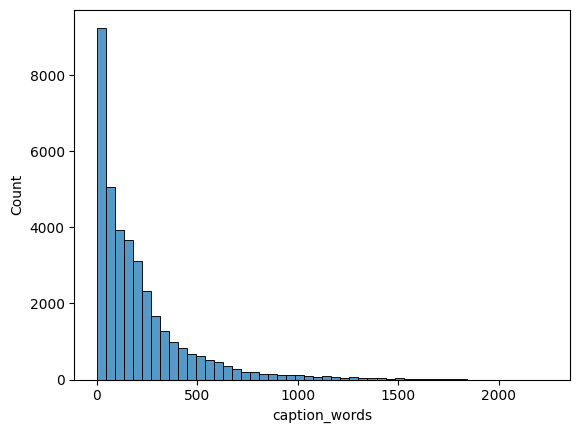

In [25]:
import seaborn as sns

df["caption_words"] = df["Captions"].str.split().str.len()
df["caption_words"].describe()

sns.histplot(df["caption_words"], bins=50)

In [26]:
# How many are under 5 words 
(df["caption_words"] < 5).sum()

np.int64(439)

In [27]:
all_words = " ".join(df["Captions"].dropna()).lower().split()
vocab = Counter(all_words)
hapax = sum(1 for w, c in vocab.items() if c == 1)
print(f"Vocabulary size: {len(vocab):,}")
print(f"Words used only once: {hapax:,} ({hapax/len(vocab):.1%} of vocab)")

Vocabulary size: 328,206
Words used only once: 193,549 (59.0% of vocab)


### 1.6 Label Distribution

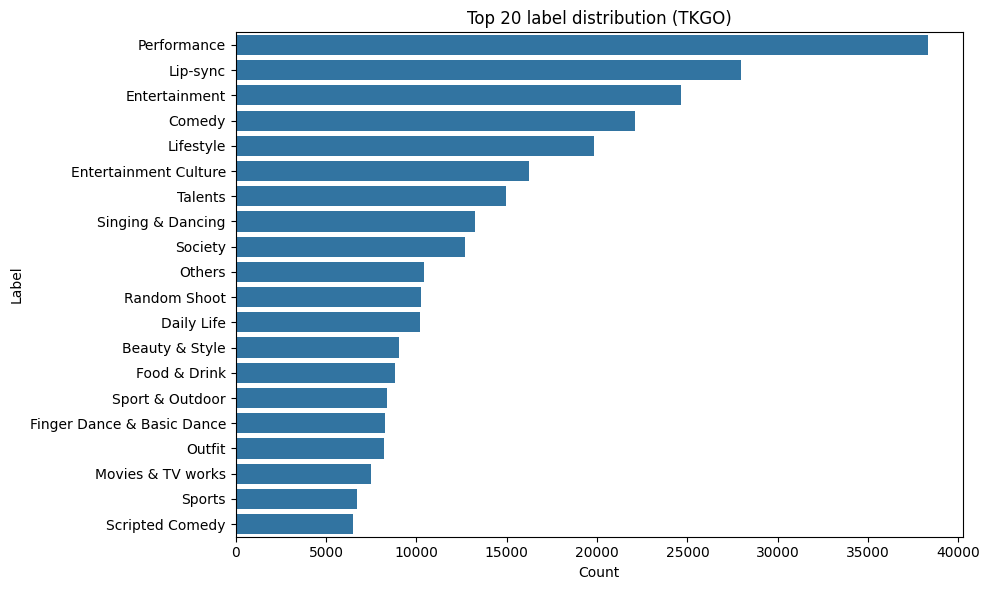

In [28]:
top_labels = label_df.head(20)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_labels, x="Count", y="Label")
plt.title("Top 20 label distribution (TKGO)")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

### 1.7 Caption Representativeness

A key question for this study is whether videos with captions are representative of the full dataset. 
If captioned videos cluster in specific content categories, any model trained on them may not generalise well to the full label space. 
The chart below compares the normalised label distribution of captioned vs non-captioned videos. 
Significant divergence between the two distributions would indicate selection bias introduced by caption availability.

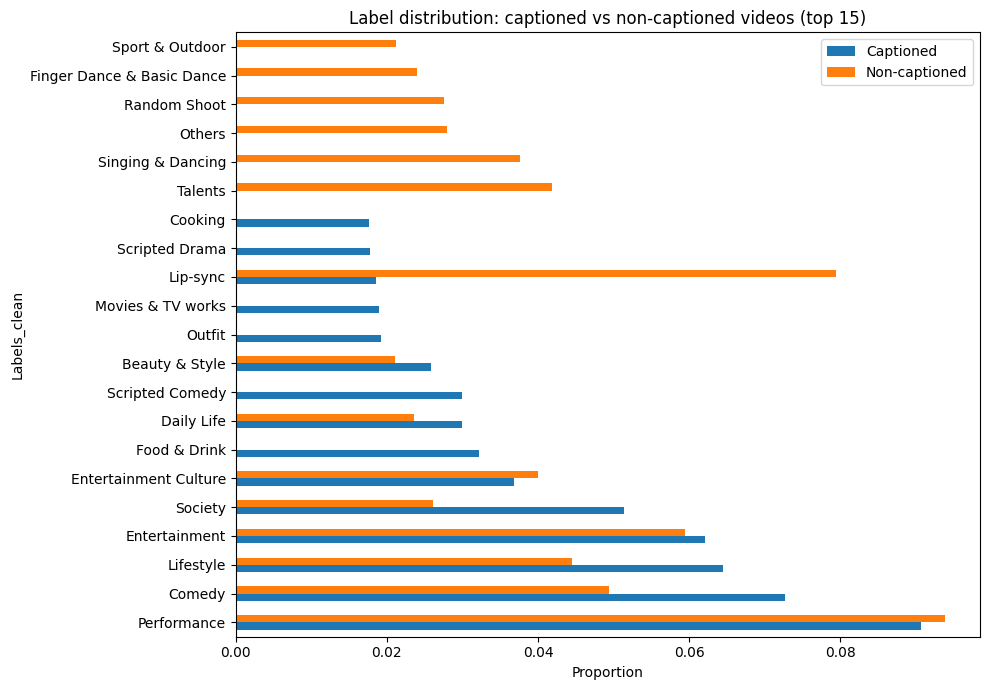

                            Captioned  Non-captioned
Labels_clean                                        
Performance                     0.091          0.094
Comedy                          0.073          0.049
Lifestyle                       0.065          0.045
Entertainment                   0.062          0.059
Society                         0.051          0.026
Entertainment Culture           0.037          0.040
Food & Drink                    0.032          0.000
Daily Life                      0.030          0.024
Scripted Comedy                 0.030          0.000
Beauty & Style                  0.026          0.021
Outfit                          0.019          0.000
Movies & TV works               0.019          0.000
Lip-sync                        0.019          0.079
Scripted Drama                  0.018          0.000
Cooking                         0.018          0.000
Talents                         0.000          0.042
Singing & Dancing               0.000         

In [29]:
valid_cap = valid_caption_mask(df["Captions"])

captioned_labels = (
    df[valid_cap]["Labels_clean"]
    .explode().dropna()
    .loc[lambda x: x != ""]
    .value_counts(normalize=True)
    .head(15)
    .rename("Captioned")
)

non_captioned_labels = (
    df[~valid_cap]["Labels_clean"]
    .explode().dropna()
    .loc[lambda x: x != ""]
    .value_counts(normalize=True)
    .head(15)
    .rename("Non-captioned")
)

comparison = pd.concat([captioned_labels, non_captioned_labels], axis=1).fillna(0)
comparison.plot(kind="barh", figsize=(10, 7))
plt.title("Label distribution: captioned vs non-captioned videos (top 15)")
plt.xlabel("Proportion")
plt.tight_layout()
plt.show()

print(comparison.round(3))

### 1.8 TF-IDF Baseline

To establish a meaningful baseline, a TF-IDF + Logistic Regression classifier is trained on the enriched TKGO captions. 
This mirrors the approach used for YouTube-8M-Text and provides a concrete micro-F1 and macro-F1 score that any subsequent model must exceed. 
Only videos with at least one label and a caption of at least 2 tokens after cleaning are included.

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, precision_score, recall_score
import re

def clean_text(s):
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = re.sub(r"(https?://\S+|www\.\S+)", "", s)
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

# Prepare TKGO — captioned videos with at least one label
df_tkgo_model = df[valid_cap & df["Labels_clean"].apply(len).gt(0)].copy()
df_tkgo_model["text"] = df_tkgo_model["Captions"].apply(clean_text)
df_tkgo_model = df_tkgo_model[
    df_tkgo_model["text"].str.split().apply(len) >= 2
].reset_index(drop=True)

print(f"Model-ready videos : {len(df_tkgo_model):,}")
print(f"Dropped (too short): {df[valid_cap & df['Labels_clean'].apply(len).gt(0)].shape[0] - len(df_tkgo_model):,}")
print(f"Label space        : {df_tkgo_model['Labels_clean'].explode().nunique()} unique labels")

mlb_tkgo = MultiLabelBinarizer()
Y_tkgo = mlb_tkgo.fit_transform(df_tkgo_model["Labels_clean"])
X_tkgo = df_tkgo_model["text"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X_tkgo, Y_tkgo, test_size=0.2, random_state=42
)
print(f"\nTrain: {len(X_train):,}  Test: {len(X_test):,}")

Model-ready videos : 26,781
Dropped (too short): 450
Label space        : 99 unique labels

Train: 21,424  Test: 5,357


In [31]:
model_tkgo = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", OneVsRestClassifier(
        LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")
    ))
])

model_tkgo.fit(X_train, Y_train)
Y_prob_tkgo = model_tkgo.predict_proba(X_test)

best_tkgo = None
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    Y_pred = (Y_prob_tkgo >= t).astype(int)
    f1 = f1_score(Y_test, Y_pred, average="micro", zero_division=0)
    if best_tkgo is None or f1 > best_tkgo[1]:
        best_tkgo = (t, f1)

Y_pred_tkgo = (Y_prob_tkgo >= best_tkgo[0]).astype(int)

print("TF-IDF Baseline (TKGO Captions): ")
print(f"Best threshold : {best_tkgo[0]}")
print(f"Micro Precision: {precision_score(Y_test, Y_pred_tkgo, average='micro', zero_division=0):.4f}")
print(f"Micro Recall   : {recall_score(Y_test, Y_pred_tkgo, average='micro', zero_division=0):.4f}")
print(f"Micro F1       : {f1_score(Y_test, Y_pred_tkgo, average='micro', zero_division=0):.4f}")
print(f"Macro F1       : {f1_score(Y_test, Y_pred_tkgo, average='macro', zero_division=0):.4f}")

TF-IDF Baseline (TKGO Captions): 
Best threshold : 0.5
Micro Precision: 0.2628
Micro Recall   : 0.5799
Micro F1       : 0.3617
Macro F1       : 0.2544


## 2. YouTube-8M-Text

In [32]:
df_yt = pd.read_csv("../data/Youtube/yt8m_merged.csv")

print(f"Shape: {df_yt.shape}")
print(f"Columns: {list(df_yt.columns)}")

Shape: (225042, 14)
Columns: ['yt8m_id', 'YouTube_id', 'label_ids_json', 'label_names_json', 'num_labels', 'mean_rgb_json', 'mean_audio_json', 'rgb_dim', 'audio_dim', 'title', 'tags_json', 'channelTitle', 'publishedAt', 'status']


### 2.1 Corpus Overview

The YouTube-8M-Text dataset contains **225,042 videos** with multi-label annotations and textual metadata. 
Unlike TKGO where the primary text feature is spoken captions (with limited coverage), 
YouTube-8M-Text relies on video **titles** and **tags** as textual features, which are available for the majority of videos (84–90%). 
This makes it a higher-coverage but metadata-based alternative to caption-driven text features.

The missing values table below shows that `mean_rgb_json` and `mean_audio_json` contain pre-extracted audio-visual features from the original YouTube-8M dataset. 
These are not used in this thesis, which focuses on the textual features.

In [33]:
missing_yt = pd.DataFrame({
    "Missing Count": df_yt.isnull().sum(),
    "Missing %": (df_yt.isnull().sum() / len(df_yt) * 100).round(2),
    "Dtype": df_yt.dtypes
}).sort_values("Missing %", ascending=False)

missing_yt.style.background_gradient(subset=["Missing %"], cmap="Reds")

,Missing Count,Missing %,Dtype
title,34963,15.540000,object
channelTitle,34963,15.540000,object
publishedAt,34963,15.540000,object
YouTube_id,23095,10.260000,object
tags_json,23095,10.260000,object
status,23095,10.260000,object
yt8m_id,0,0.000000,object
label_ids_json,0,0.000000,object
label_names_json,0,0.000000,object
num_labels,0,0.000000,int64


### 2.2 Text Feature Coverage and Analysis

Title and tag coverage are both above 84%. Tags are stored as a JSON list and are parsed into a flat string for analysis. 
The length distributions and vocabulary statistics below characterise the richness of each text feature. 
The high hapax rate in both title and tag vocabularies (~65–75%) reflects the diversity of video content and the presence of proper nouns, 
channel-specific terminology, and rare topic keywords.

In [34]:
def valid_text_mask(series):
    return (
        series.notna() &
        (series.astype(str).str.strip() != "")
    )

title_cov = valid_text_mask(df_yt["title"])
tags_cov  = valid_text_mask(df_yt["tags_json"])

print("Text Feature Coverage:")
print(f"{'Title':20s}: {title_cov.sum():>7,} ({title_cov.mean():.2%})")
print(f"{'Tags':20s}: {tags_cov.sum():>7,} ({tags_cov.mean():.2%})")
print(f"{'Either':20s}: {(title_cov | tags_cov).sum():>7,} ({(title_cov | tags_cov).mean():.2%})")
print(f"{'Both':20s}: {(title_cov & tags_cov).sum():>7,} ({(title_cov & tags_cov).mean():.2%})")


Text Feature Coverage:
Title               : 190,079 (84.46%)
Tags                : 201,947 (89.74%)
Either              : 201,947 (89.74%)
Both                : 190,079 (84.46%)


In [35]:
def parse_tags(x):
    try:
        tags = json.loads(x)
        return " ".join(tags) if isinstance(tags, list) else str(x)
    except:
        return str(x) if pd.notna(x) else ""

df_yt["tags_clean"] = df_yt["tags_json"].apply(parse_tags)

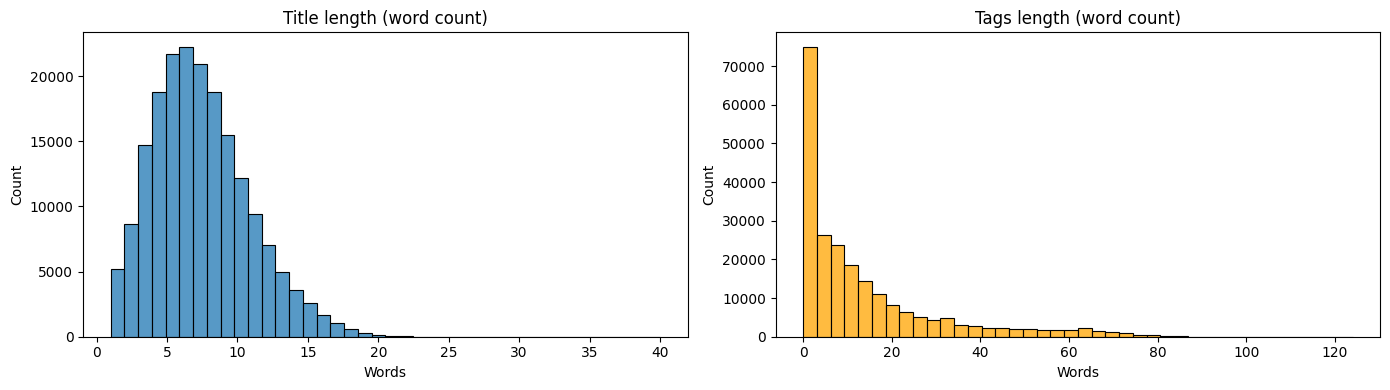

Title stats:
count    190079.0
mean          7.1
std           3.5
min           1.0
25%           5.0
50%           7.0
75%           9.0
max          40.0
Name: title_words, dtype: float64

Tags stats:
count    225042.0
mean         13.8
std          17.0
min           0.0
25%           1.0
50%           8.0
75%          18.0
max         124.0
Name: tags_words, dtype: float64


In [36]:

df_yt["title_words"] = df_yt["title"].dropna().str.split().str.len()
df_yt["tags_words"]  = df_yt["tags_clean"].dropna().str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_yt["title_words"].dropna(), bins=40, ax=axes[0])
axes[0].set_title("Title length (word count)")
axes[0].set_xlabel("Words")

sns.histplot(df_yt["tags_words"].dropna(), bins=40, ax=axes[1], color="orange")
axes[1].set_title("Tags length (word count)")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

print("Title stats:")
print(df_yt["title_words"].describe().round(1))
print("\nTags stats:")
print(df_yt["tags_words"].describe().round(1))

In [37]:
title_words = " ".join(df_yt["title"].dropna()).lower().split()
tags_words  = " ".join(df_yt["tags_clean"].dropna()).lower().split()

for name, words in [("Title", title_words), ("Tags", tags_words)]:
    vocab = Counter(words)
    hapax = sum(1 for w, c in vocab.items() if c == 1)
    print(f"{name}:")
    print(f"  Vocabulary size : {len(vocab):,}")
    print(f"  Words used only once  : {hapax:,} ({hapax/len(vocab):.1%})")
    print()

Title:
  Vocabulary size : 306,000
  Words used only once  : 231,107 (75.5%)

Tags:
  Vocabulary size : 429,745
  Words used only once  : 283,297 (65.9%)



### 2.3 Label Analysis

YouTube-8M-Text uses a substantially larger label vocabulary than TKGO (3,860 labels vs 101). 
All videos have at least one label assigned, with an average of 3 labels per video. 
The dominant labels (Games, Vehicle, Video game) reflect the composition of the YouTube-8M corpus, 
which over-represents gaming and automotive content relative to general web video. 
This label distribution should be kept in mind when comparing model performance across the two datasets.

In [38]:
def parse_label_names(x):
    try:
        return json.loads(x)
    except:
        return []

df_yt["labels_parsed"] = df_yt["label_names_json"].apply(parse_label_names)
df_yt["num_labels"]    = df_yt["labels_parsed"].apply(len)

with_labels_yt = df_yt["num_labels"].gt(0).sum()
print(f"Videos with labels : {with_labels_yt:,} ({with_labels_yt/len(df_yt):.2%})")
print(f"Avg labels/video   : {df_yt['num_labels'].mean():.2f}")

Videos with labels : 225,042 (100.00%)
Avg labels/video   : 3.01


### 2.4 TF-IDF Baseline

A TF-IDF + Logistic Regression classifier is trained on the combined title and tag text features. 
Text is preprocessed by lowercasing, removing URLs and punctuation, and combining title and tags into a single field. 
Videos with fewer than 2 tokens after cleaning are excluded. 
This mirrors the TKGO baseline setup to allow direct comparison.

In [39]:
def tags_to_text(x):
    if not isinstance(x, str):
        return ""
    try:
        tags = json.loads(x)
        if isinstance(tags, list):
            return " ".join(tags)
    except Exception:
        pass
    return ""

# Build text feature
df_yt["text"] = (
    df_yt["title"].apply(clean_text) + " " +
    df_yt["tags_json"].apply(tags_to_text).apply(clean_text)
).str.strip()

df_yt["label_ids"] = df_yt["label_ids_json"].apply(
    lambda x: json.loads(x) if isinstance(x, str) else []
)

df_yt_model = df_yt[
    df_yt["text"].str.split().apply(len) >= 2
].reset_index(drop=True)

print(f"Model-ready videos : {len(df_yt_model):,}")
print(f"Dropped (too short): {len(df_yt) - len(df_yt_model):,}")
print(f"Label space        : {df_yt['label_ids'].explode().nunique():,} unique labels")

mlb_yt = MultiLabelBinarizer()
Y_yt = mlb_yt.fit_transform(df_yt_model["label_ids"])
X_yt = df_yt_model["text"]

X_train_yt, X_test_yt, Y_train_yt, Y_test_yt = train_test_split(
    X_yt, Y_yt, test_size=0.2, random_state=42
)
print(f"\nTrain: {len(X_train_yt):,}  Test: {len(X_test_yt):,}")

Model-ready videos : 183,232
Dropped (too short): 41,810
Label space        : 3,862 unique labels

Train: 146,585  Test: 36,647


In [41]:
model_yt = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", OneVsRestClassifier(
        LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")
    ))
])

model_yt.fit(X_train_yt, Y_train_yt)
Y_prob_yt = model_yt.predict_proba(X_test_yt)

best_yt = None
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    Y_pred = (Y_prob_yt >= t).astype(int)
    f1 = f1_score(Y_test_yt, Y_pred, average="micro", zero_division=0)
    if best_yt is None or f1 > best_yt[1]:
        best_yt = (t, f1)

Y_pred_yt = (Y_prob_yt >= best_yt[0]).astype(int)

print("TF-IDF Baseline (YouTube-8M-Text): ")
print(f"Best threshold : {best_yt[0]}")
print(f"Micro Precision: {precision_score(Y_test_yt, Y_pred_yt, average='micro', zero_division=0):.4f}")
print(f"Micro Recall   : {recall_score(Y_test_yt, Y_pred_yt, average='micro', zero_division=0):.4f}")
print(f"Micro F1       : {f1_score(Y_test_yt, Y_pred_yt, average='micro', zero_division=0):.4f}")
print(f"Macro F1       : {f1_score(Y_test_yt, Y_pred_yt, average='macro', zero_division=0):.4f}")

/Users/christosgeorghiou/anaconda3/envs/MyEnvironment1/lib/python3.12/site-packages/sklearn/multiclass.py:90: UserWarning: Label not 3655 is present in all training examples.
  warnings.warn(
/Users/christosgeorghiou/anaconda3/envs/MyEnvironment1/lib/python3.12/site-packages/sklearn/multiclass.py:90: UserWarning: Label not 3839 is present in all training examples.
  warnings.warn(


TF-IDF Baseline (YouTube-8M-Text): 
Best threshold : 0.5
Micro Precision: 0.3973
Micro Recall   : 0.7524
Micro F1       : 0.5200
Macro F1       : 0.3877


## 3. Dataset Comparison

The two datasets differ substantially in scale, text feature type, coverage, and label space. 
TKGO provides short-form social video data with spoken captions as the primary text signal, 
while YouTube-8M-Text provides large-scale web video data with metadata-based text features (titles and tags). 
The table below summarises the key differences relevant to this thesis.

In [43]:
# Summary comparison of both baselines
micro_f1_tkgo = f1_score(Y_test, Y_pred_tkgo, average='micro', zero_division=0)
macro_f1_tkgo = f1_score(Y_test, Y_pred_tkgo, average='macro', zero_division=0)
micro_f1_yt   = f1_score(Y_test_yt, Y_pred_yt, average='micro', zero_division=0)
macro_f1_yt   = f1_score(Y_test_yt, Y_pred_yt, average='macro', zero_division=0)

text_coverage_yt = len(df_yt_model) / len(df_yt)

print("Dataset Comparison: TKGO vs YouTube-8M-Text:\n")
print(f"{'':35s} {'TKGO':>15} {'YouTube-8M-T':>15}")
print(f"{'Videos (total)':35s} {len(df):>15,} {len(df_yt):>15,}")
print(f"{'Videos (model-ready)':35s} {len(df_tkgo_model):>15,} {len(df_yt_model):>15,}")
print(f"{'Unique labels':35s} {'101':>15} {Y_yt.shape[1]:>15,}")
print(f"{'Avg labels/video':35s} {df['num_labels'].mean():>15.2f} {df_yt['num_labels'].mean():>15.2f}")
print(f"{'Text feature':35s} {'Captions':>15} {'Title + Tags':>15}")
print(f"{'Text coverage':35s} {valid_cap.mean():>15.2%} {text_coverage_yt:>15.2%}")
print(f"{'Text type':35s} {'Speech':>15} {'Metadata':>15}")
print(f"{'-'*67}")
print(f"{'TF-IDF Micro F1':35s} {micro_f1_tkgo:>15.4f} {micro_f1_yt:>15.4f}")
print(f"{'TF-IDF Macro F1':35s} {macro_f1_tkgo:>15.4f} {macro_f1_yt:>15.4f}")

Dataset Comparison: TKGO vs YouTube-8M-Text:

                                               TKGO    YouTube-8M-T
Videos (total)                              222,552         225,042
Videos (model-ready)                         26,781         183,232
Unique labels                                   101           3,860
Avg labels/video                               1.85            3.01
Text feature                               Captions    Title + Tags
Text coverage                                16.56%          81.42%
Text type                                    Speech        Metadata
-------------------------------------------------------------------
TF-IDF Micro F1                              0.3617          0.5200
TF-IDF Macro F1                              0.2544          0.3877
